# Protein Groups Analysis – Mouse Embryonic Cells (MEC)

## Overview

This notebook performs comparative analysis of **protein group identifications** across different processing pipelines (e.g., *Standard* vs *SBM 3*) for mouse embryonic fibroblast datasets.  

It focuses on:

- Filtering and cleaning protein group outputs
- Comparing dataset-specific protein identifications
- Quantifying intensity distributions
- Identifying uniquely detected proteins
- Performing Gene Ontology (GO) enrichment summaries
- Exploring subcellular localization
- Visualizing overlaps using UpSet plots


## Input Data

### 1. Protein Group Files
Tab-delimited `proteinGroups.txt` files from different workflows:

- `SBM 3`
- `Standard`

These are loaded from:
'''../mouse_embro_fibroblasts/DATASET/txt/proteinGroups.txt'''


### The notebook produces:

* Bar charts of protein counts per dataset
* Rank-intensity scatter plots
* Intensity distribution histograms
* GO enrichment bar plots
* Counts of unique proteins and genes with subcellular localization summaries


The plots are shown in Figure 6, with some extra plots beeing shown here. 

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from upsetplot import UpSet
import textwrap

import re
from collections import Counter

plt.rcParams["font.family"] = "Arial" 

%load_ext autoreload
from protein_inference import * 

In [2]:
color_map = {
    '0': '#ffbc42',
    'VM': '#ffbc42',
    'SBM 0': '#ffbc42',
    'sbm_o_4': '#2ca02c', 
    'st':    '#d81159', 
    'Standard':    '#d81159', 
    'Unique Standard':    '#d81159',
    'sbm_3': '#73d2de', 
    'SBM 3': '#73d2de', 
    'MQ SBM 3': '#73d2de', 
    'MQ SBM 3 Percolator': '#b7e8ee', 
    'sbm3': '#73d2de',
    'Unique SBM 3': '#73d2de',
    'sbm_8': '#218380',
    'sbm8': '#218380',
    'SBM 8': '#218380', 
    'MSFragger': '#60435f', 
    'MSFragger 9nl Percolator': '#60435f', 
    'Unique MSFragger': '#60435f'
}

custom_order = ['Standard', 'SBM 3']

# Importing the data

In [ ]:
root_dir = '../mouse_embro_fibroblasts' 
f_path = "../MOUSE.fasta"

pg_sbm3 = "../mouse_embro_fibroblasts/SBM 3/txt/proteinGroups.txt"
pg_st = "../mouse_embro_fibroblasts/Standard/txt/proteinGroups.txt"

# file with genes and their assosiated subcellular compartment 
comp_file = '../compartments/mouse_compartment_integrated_full_filtered.tsv'

In [4]:
def process_dataframe(file_path, site_column, dataset_name):
    """
    Load and clean a MaxQuant proteinGroups file for SUMO site analysis.

    Removes potential contaminants and reverse hits, filters for valid
    modification site entries, standardizes the SUMO site column name,
    and adds a dataset label.

    Parameters
    ----------
    file_path : str
        Path to the tab-delimited proteinGroups.txt file.
    site_column : str
        Name of the dataset-specific SUMO site column.
    dataset_name : str
        Label assigned to the dataset (e.g., "Standard", "SBM 3").

    Returns
    -------
    pandas.DataFrame
        Filtered dataframe with standardized
        'SUMO2/3-DVFQQQTGG site positions' and added 'Dataset' column.
    """
    df = pd.read_csv(file_path, delimiter="\t")
    df = df[df['Potential contaminant'] != '+']
    df['Reverse'].fillna('-', inplace=True)
    df = df[df['Reverse'] != '+']
    df[site_column].fillna('-', inplace=True)
    df = df[df[site_column] != '-']
        
    df['SUMO2/3-DVFQQQTGG site positions'] = df[site_column]
    df['Dataset'] = dataset_name
    
    return df

df_pg_st = process_dataframe(pg_st, 'st_o_SUMO2/3-DVFQQQTGG site positions', 'Standard')
df_pg_sbm3 = process_dataframe(pg_sbm3, 'SBM_3_o_SUMO2/3-DVFQQQTGG site positions', 'SBM 3')

pg_dfs = pd.concat([df_pg_sbm3, df_pg_st], ignore_index=True)

In [5]:
%autoreload 2

pg_dfs = protein_inference_pg(pg_dfs, species ='mouse') # custom function, look into protein_inference.py for details

/Users/hmt128/miniconda3/lib/python3.11/site-packages/biotite/sequence/io/fasta/convert.py:248: UserWarning: ProteinSequence objects do not support selenocysteine (U), occurrences were substituted by cysteine (C)
  warnings.warn(


In [9]:
print(f"Total SBM 3 proteins: {len(df_sbm_3)}")
print(f"SBM 3 with valid Protein IDs: {df_sbm_3['Protein IDs'].notna().sum()}")
print(f"Unique SBM 3 Protein IDs: {df_sbm_3['Protein IDs'].nunique()}")

print(f"Set size (original): {len(set(df_sbm_3['Protein IDs']) - set(df_st['Protein IDs']))}")

Total SBM 3 proteins: 733
SBM 3 with valid Protein IDs: 733
Unique SBM 3 Protein IDs: 733
Set size (original): 168


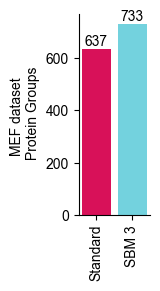

In [16]:
filtered_counts_results = pg_dfs.groupby('Dataset').size()
sorted_counts_pgs = filtered_counts_results.reindex(custom_order)

fig, ax = plt.subplots(figsize=(1.7, 3))

bars = ax.bar(
    sorted_counts_pgs.index, 
    sorted_counts_pgs.values, 
    color=[color_map.get(dataset, 'grey') for dataset in sorted_counts_pgs.index]
)

# Uncomment to display bar values on top
for bar in bars:
     height = bar.get_height()
     ax.text(bar.get_x() + bar.get_width() / 2.0, height, '%d' % int(height), ha='center', va='bottom')

ax.set_xlabel('')
ax.set_ylabel('MEF dataset \n Protein Groups')
ax.set_title('')
ax.set_xticks(range(len(sorted_counts_pgs.index)))
ax.set_xticklabels(sorted_counts_pgs.index, rotation=90) 
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.yaxis.set_major_formatter(ticker.EngFormatter())

plt.tight_layout()
file_path = fig_dir + "Protein_groups.pdf"
plt.savefig(file_path, transparent=True)
plt.show()

/Users/hmt128/miniconda3/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_9337/1716672429.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sbm_3['Intensity_log2'] = np.log2(df_sbm_3['Intensity'])
/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_9337/1716672429.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sbm_3['

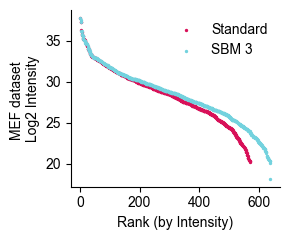

In [18]:

df_sbm_3['Intensity_log2'] = np.log2(df_sbm_3['Intensity'])
df_sbm_3['Rank'] = df_sbm_3['Intensity_log2'].rank(ascending=False)

df_st['Intensity_log2'] = np.log2(df_st['Intensity'])
df_st['Rank'] = df_st['Intensity_log2'].rank(ascending=False)

df_sbm_3 = df_sbm_3[np.isfinite(df_sbm_3['Intensity_log2'])]
df_st = df_st[np.isfinite(df_st['Intensity_log2'])]

fig, ax = plt.subplots(figsize=(3, 2.5))

ax.scatter(df_st['Rank'], df_st['Intensity_log2'], color=color_map["st"], s=2, label="Standard")
ax.scatter(df_sbm_3['Rank'], df_sbm_3['Intensity_log2'], color=color_map["sbm3"], s=2, label="SBM 3")

ax.set_xlabel('Rank (by Intensity)')
ax.set_ylabel('MEF dataset \nLog2 Intensity')
ax.set_title('')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)
plt.tight_layout()
plt.legend(frameon=False)
file_path = fig_dir + "dynamic_range.pdf"
plt.savefig(file_path, transparent=True)
plt.show()

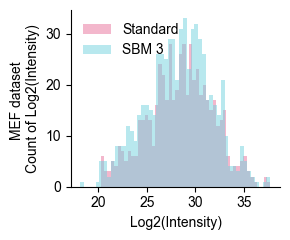

In [19]:
fig, ax = plt.subplots(figsize=(3, 2.5))

ax.hist(df_st['Intensity_log2'], bins=50, color=color_map["st"], alpha=0.3, density=False, label="Standard")
ax.hist(df_sbm_3['Intensity_log2'], bins=50, color=color_map["sbm3"], alpha=0.5, density=False, label="SBM 3")

ax.set_xlabel('Log2(Intensity)')
ax.set_ylabel('MEF dataset \nCount of Log2(Intensity)')
ax.set_title('')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.legend(frameon=False) 
plt.tight_layout()

# Save and show the plot
file_path = fig_dir + "log2_intensity_histogram.pdf"
plt.savefig(file_path, transparent=True)
plt.show()

/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_9337/748975109.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=key_counts.index, x=key_counts.values, palette='mako')
/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_9337/748975109.py:21: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


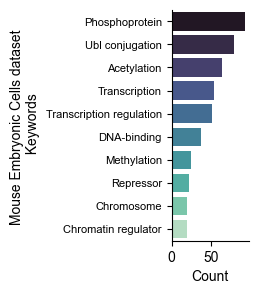

In [22]:
exclude = ["Nucleus", "Reference proteome", "Cytoplasm", "3D-structure", "Repeat", "Direct protein sequencing", "Coiled coil", "Isopeptide bond", "Metal-binding", "Zinc", "Zinc-finger", "Alternative splicing"]

unique_protein_ids = set(df_sbm_3['Protein IDs']) - set(df_st['Protein IDs'])
unique_proteins = df_sbm_3[df_sbm_3['Protein IDs'].isin(unique_protein_ids)]

key_terms = unique_proteins['Keywords'].dropna().str.split(';').explode().str.strip()
key_terms = key_terms[~key_terms.isin(exclude)]

key_counts = key_terms.value_counts().head(10)

wrap_width = 40
key_counts.index = [textwrap.fill(label, wrap_width) for label in key_counts.index]

plt.figure(figsize=(1,3))
sns.barplot(y=key_counts.index, x=key_counts.values, palette='mako')
plt.xlabel("Count")
plt.ylabel("Mouse Embryonic Cells dataset \n Keywords")
plt.yticks(fontsize=8) 
#plt.title("Top 10 GO Biological Processes (Unique to SBM 3)")
sns.despine(top=True, right=True)
plt.tight_layout()
file_path = fig_dir + "keywords.pdf"
plt.savefig(file_path, transparent=True, bbox_inches='tight')
plt.show()

/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_9337/50231544.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=go_counts.index, x=go_counts.values, palette='mako')
/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_9337/50231544.py:20: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


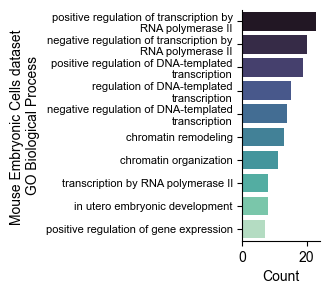

In [23]:
unique_protein_ids = set(df_sbm_3['Protein IDs']) - set(df_st['Protein IDs'])

unique_proteins = df_sbm_3[df_sbm_3['Protein IDs'].isin(unique_protein_ids)]

go_column = 'Gene Ontology (biological process)'
go_terms = unique_proteins[go_column].dropna().str.split(';').explode().str.strip()
go_terms_cleaned = go_terms.str.replace(r'\[.*?\]', '', regex=True).str.strip()
go_counts = go_terms_cleaned.value_counts().head(10)

wrap_width = 40
go_counts.index = [textwrap.fill(label, wrap_width) for label in go_counts.index]

plt.figure(figsize=(1,3))
sns.barplot(y=go_counts.index, x=go_counts.values, palette='mako')
plt.xlabel("Count")
plt.ylabel("Mouse Embryonic Cells dataset \nGO Biological Process")
plt.yticks(fontsize=8) 
#plt.title("Top 10 GO Biological Processes (Unique to SBM 3)")
sns.despine(top=True, right=True)
plt.tight_layout()
file_path = fig_dir + "bio_processes.pdf"
plt.savefig(file_path, transparent=True, bbox_inches='tight')
plt.show()

/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_9337/2912915868.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=go_counts.index, x=go_counts.values, palette='mako')
/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_9337/2912915868.py:16: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


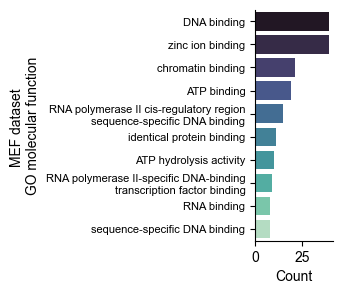

In [24]:
go_column = 'Gene Ontology (molecular function)'
go_terms = unique_proteins[go_column].dropna().str.split(';').explode().str.strip()

go_terms_cleaned = go_terms.str.replace(r'\[.*?\]', '', regex=True).str.strip()
go_counts = go_terms_cleaned.value_counts().head(10)

go_counts.index = [textwrap.fill(label, wrap_width) for label in go_counts.index]

plt.figure(figsize=(1, 3))
sns.barplot(y=go_counts.index, x=go_counts.values, palette='mako')
plt.yticks(fontsize=8) 
plt.xlabel("Count")
plt.ylabel("MEF dataset \nGO molecular function")
#plt.title("Top 10 GO Molecular Function (Unique to SBM 3)")
sns.despine(top=True, right=True)
plt.tight_layout()
file_path = fig_dir + "bio_molfunc.pdf"
plt.savefig(file_path, transparent=True, bbox_inches='tight')
plt.show()

In [27]:
comp = pd.read_csv(comp_file, sep = '\t', header =None)
comp = comp[comp[4] >= 3]

# simplyfing the cellular compartments a bit since we are mainly looking to compare nucleus or not nucleus.  
comp[3] = comp[3].str.replace('Cytoskeleton', 'Cytosol').str.replace('Peroxisome', 'Cytosol').str.replace('Lysosome', 'Cytosol').str.replace('Endoplasmic reticulum', 'Cytosol').str.replace('Endosome', 'Cytosol').str.replace('Golgi apparatus', 'Cytosol').str.replace('Mitochondrion', 'Cytosol')

column_rename_map = {
    1: 'Gene_name',
    3: 'Gene Ontology (cellular component)'
}

comp.rename(columns=column_rename_map, inplace=True)

comp = comp.drop_duplicates(subset=['Gene_name', 'Gene Ontology (cellular component)'])

comp_joined = comp.groupby('Gene_name', as_index=False)['Gene Ontology (cellular component)'].apply(lambda x: ', '.join(x)).reset_index(drop=True)
comp_joined['Gene Ontology (cellular component)'] = comp_joined['Gene Ontology (cellular component)'].apply(
    lambda x: ', '.join(
        sorted(x.split(', '), key=lambda y: (y != 'Nucleus', y))
    )
)

In [28]:
dataset_names = pg_dfs['Dataset'].unique()

dataset_gene_sets = {
    name: set(pg_dfs[pg_dfs['Dataset'] == name]['Gene_name'])
    for name in dataset_names
}

all_gene_names = set().union(*dataset_gene_sets.values())

data_gns = []
for gene in all_gene_names:
    row = [gene in gene_set for gene_set in dataset_gene_sets.values()]
    row.append(gene)
    data_gns.append(row)

column_names = list(dataset_gene_sets.keys()) + ['Gene_name']
df_overlap = pd.DataFrame(data_gns, columns=column_names)

df_overlap = df_overlap.merge(comp_joined, on='Gene_name', how='left')
df_overlap['Gene Ontology (cellular component)'] = df_overlap['Gene Ontology (cellular component)'].fillna("Unknown")

df_overlap.set_index(column_names[:-1], inplace=True)


In [29]:
pg_dfs_dedup = pg_dfs.drop_duplicates(subset=['Protein IDs', 'Dataset'])

dataset_names = pg_dfs_dedup['Dataset'].unique()
dataset_protein_sets = {
    name: set(pg_dfs_dedup[pg_dfs_dedup['Dataset'] == name]['Protein IDs'].dropna())
    for name in dataset_names
}

all_protein_ids = set().union(*dataset_protein_sets.values())

data = []
for protein_id in all_protein_ids:
    row = [protein_id in dataset_protein_sets[name] for name in dataset_names]
    row.append(protein_id)
    data.append(row)

column_names = list(dataset_protein_sets.keys()) + ['Protein IDs']
df_overlap = pd.DataFrame(data, columns=column_names)

protein_to_gene = (
    pg_dfs_dedup.groupby('Protein IDs')['Gene_name']
    .first()  
    .reset_index()
)
df_overlap = df_overlap.merge(protein_to_gene, on='Protein IDs', how='left')

df_overlap = df_overlap.merge(comp_joined, on='Gene_name', how='left')
df_overlap['Gene Ontology (cellular component)'] = df_overlap['Gene Ontology (cellular component)'].fillna("Unknown")

df_overlap.set_index(column_names[:-1], inplace=True)

In [30]:
df_overlap = df_overlap.drop_duplicates(subset='Protein IDs')


df_overlap

Protein IDs Gene_name  \
SBM 3 Standard                                                   
True  False     F6W8R9;Q6DFZ2;E9QP46;Q6ZWQ0-3;Q6ZWQ0     Syne2   
      True                                    Q61335    Bcap31   
      True                             Q8CG48;B1AWH6      Smc2   
      False                                   Q9D168    Ints12   
      True        E9Q7S1;R4GML0;F6UL00;F6QFS1;E9PVH6    Zfp106   
...                                              ...       ...   
      True                Q8CG46-2;Q8CG46;A0A286YDG5      Smc5   
      True                           Q6P5G3;Q6P5G3-2     Mbtd1   
      True             D3YZC7;D3YZC8;Q8R3B7-2;Q8R3B7      Brd8   
      True                                    Q9CU62     Smc1a   
      True              Q6PAL0;A0A1L1SSB5;A0A1L1SU50     Bend3   

               Gene Ontology (cellular component)  
SBM 3 Standard                                     
True  False     Nucleus, Cytosol, Plasma membrane  
      True               Cytosol, Plasma membrane  
      True                                Nucleus  
      False                               Nucleus  
      True                       Nucleus, Cytosol  
...                                           ...  
      True                                Nucleus  
      True                                Nucleus  
      True                                Nucleus  
      True                       Nucleus, Cytosol  
      True                                Nucleus  

[805 rows x 3 columns]

In [31]:
df_temp = df_overlap.reset_index()

dataset_columns = [col for col in df_temp.columns if col in dataset_names]  # assuming dataset_names includes 'SBM 3'

sbm3_only = df_temp[
    (df_temp['SBM 3']) &
    (df_temp[[col for col in dataset_columns if col != 'SBM 3']].sum(axis=1) == 0)
]

print(f"SBM 3-only genes: {len(sbm3_only)}")


SBM 3-only genes: 168


In [32]:
categories = df_overlap['Gene Ontology (cellular component)'].dropna().unique().tolist()
categories.sort()  # Optional: sort alphabetically
print(categories)

space_colors = {
    'Cytosol': '#1f77b4',
    'Cytosol, Extracellular space': '#5fa9dd',
    'Cytosol, Extracellular space, Plasma membrane': '#94c7ec',
    'Cytosol, Plasma membrane': '#bcdcf5',
    
    'Extracellular space': '#658a4c',
    'Extracellular space, Plasma membrane': '#82ad62',
    'Plasma membrane': '#98c574',
    
    'Nucleus': '#ffba08',
    'Nucleus, Cytosol': '#faa307',
    'Nucleus, Cytosol, Extracellular space': '#e85d04',
    'Nucleus, Cytosol, Extracellular space, Plasma membrane': '#dc2f02',
    'Nucleus, Cytosol, Plasma membrane': '#d00000',
    'Nucleus, Extracellular space': '#9d0208',
    'Nucleus, Extracellular space, Plasma membrane': '#6a040f',
    'Nucleus, Plasma membrane': '#370617',

    'Unknown': '#7f7f7f'
}

['Cytosol', 'Cytosol, Extracellular space', 'Cytosol, Extracellular space, Plasma membrane', 'Cytosol, Plasma membrane', 'Extracellular space', 'Nucleus', 'Nucleus, Cytosol', 'Nucleus, Cytosol, Extracellular space, Plasma membrane', 'Nucleus, Cytosol, Plasma membrane', 'Nucleus, Extracellular space', 'Nucleus, Plasma membrane', 'Plasma membrane', 'Unknown']


/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_9337/4241341471.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


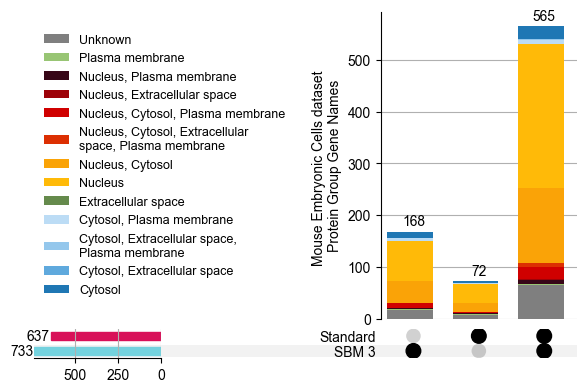

In [35]:
upset = UpSet(
    df_overlap,
    intersection_plot_elements=0,
    subset_size="count",
    min_subset_size=20, 
    show_counts=True,   
    element_size = 30, 
)

upset.add_stacked_bars(
    by='Gene Ontology (cellular component)',
    colors=space_colors,
    title='Mouse Embryonic Cells dataset \nProtein Group Gene Names',
    elements=len(space_colors)
)

for category in color_map:  
    upset.style_categories(
        [category],
        bar_facecolor=color_map.get(category, 'grey'),  
        bar_edgecolor=None 
    )

ax_dict = upset.plot()
fig = plt.gcf() 
fig.set_size_inches(7, 4.5)  

for bar in ax_dict['extra0'].patches:
    bar.set_width(0.7)
    bar.set_x(bar.get_x() - 0.15) 

handles, labels = ax_dict['extra0'].get_legend_handles_labels()
wrapped_labels = ['\n'.join(textwrap.wrap(label, 35)) for label in labels]
ax_dict['extra0'].legend(handles, wrapped_labels, frameon=False,
                         loc='center', bbox_to_anchor=(-1.1, 0.5), fontsize=9)
plt.tight_layout()
plt.gcf().savefig(fig_dir + "upset_plot_gnas.pdf", format="pdf", transparent=True, bbox_inches='tight')
plt.show()